# scikit-learn Bootcamp — W1, Day 11
```
##### Pipelines
##### Pipeline · ColumnTransformer · fit_transform vs transform · leakage prevention · joblib
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Q1 — EDA: data audit that motivates Pipeline design choices
##### Q2 — ColumnTransformer: numeric + categorical branches
##### Q3 — Full Pipeline: preprocessor + model
##### Q4 — Leakage proof: broken vs correct Pipeline comparison
##### Q5 — Save and reload the Pipeline with joblib
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold,cross_validate,GridSearchCV,RandomizedSearchCV,learning_curve,validation_curve
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score,f1_score,classification_report,precision_score,recall_score
from scipy.stats import randint,uniform
import joblib,time,warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid');np.random.seed(420)

---
### Dataset — MedPulse Mixed-Type Dataset
```
# 4,000 sessions. Mix of numeric, binary, and categorical features.
# Includes missing values to make the preprocessing realistic.
```

In [29]:
np.random.seed(420)
n=4000
age=np.random.normal(43,12,n).clip(18,80).astype(int)
session_depth=np.random.poisson(3.8,n).clip(1,20)
time_on_site=np.random.lognormal(1.7,0.75,n).clip(0.5,80)
articles_read=np.random.poisson(2.5,n).clip(0,15)
is_mobile=np.random.binomial(1,0.59,n)
health_content=np.random.beta(2.5,2,n)
device_type=np.random.choice(['mobile','tablet','desktop'],n,p=[0.55,0.12,0.33])
traffic_source=np.random.choice(['organic','direct','social','email'],n,p=[0.45,0.25,0.18,0.12])

# Inject 8% missing in time_on_site and 5% in health_content
miss_t=np.random.choice(n,int(n*0.08),replace=False)
miss_h=np.random.choice(n,int(n*0.05),replace=False)
time_arr=time_on_site.copy();time_arr[miss_t]=np.nan
hlth_arr=health_content.copy();hlth_arr[miss_h]=np.nan

log_odds=(-3.8+0.22*session_depth+0.06*np.where(np.isnan(time_arr),4,time_arr)+0.18*articles_read+1.1*np.where(np.isnan(hlth_arr),0.4,hlth_arr)-0.25*is_mobile+0.007*age+np.random.normal(0,0.5,n))
converted=np.random.binomial(1,1/(1+np.exp(-log_odds)))

df=pd.DataFrame({'age':age,'session_depth':session_depth,'time_on_site':time_arr.round(2),'articles_read':articles_read,'is_mobile':is_mobile,'health_content':hlth_arr.round(4),'device_type':device_type,'traffic_source':traffic_source,'converted':converted})

numeric_feats    =['age','session_depth','time_on_site','articles_read','health_content']
binary_feats     =['is_mobile']
categorical_feats=['device_type','traffic_source']
target           ='converted'

X=df[numeric_feats+binary_feats+categorical_feats]
y=df[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=420,stratify=y)
print(f'Shape: {df.shape} | Conversion: {y.mean():.2%}')
print(f'Missing: {df.isnull().sum().sum()} values')
display(df.head(5))

Shape: (4000, 9) | Conversion: 22.68%
Missing: 520 values


,age,session_depth,time_on_site,articles_read,is_mobile,health_content,device_type,traffic_source,converted
0,37,3,13.35,4,0,0.2969,tablet,organic,0
1,20,3,2.03,4,0,0.5035,mobile,direct,0
2,36,1,10.65,4,1,0.7952,desktop,email,1
3,39,8,1.84,3,1,0.3348,desktop,organic,0
4,46,2,3.63,1,1,0.4895,mobile,organic,0


---
### Q1 — EDA: data audit motivating Pipeline design
```
# (a) Missing value heatmap — where are the gaps?
# (b) Dtype table: numeric vs categorical, cardinality per column.
# (c) Conversion rate by device_type and traffic_source.
# (d) Based on the audit: sketch the ColumnTransformer architecture.
#     Which columns go to which branch?
```

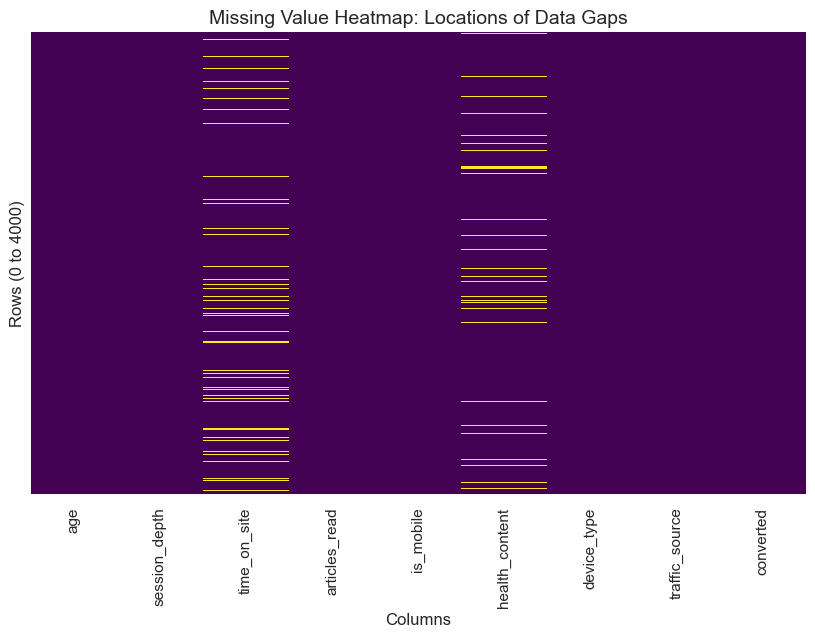

In [30]:
# (a) Missing value heatmap — where are the gaps?
plt.figure(figsize=(10, 6))

# cbar=False removes the color scale legend
# yticklabels=False hides individual row numbers for readability
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Value Heatmap: Locations of Data Gaps', fontsize=14)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Rows (0 to 4000)', fontsize=12)
plt.show()

# The gaps (missing values) are located exclusively in two columns: time_on_site and health_content

In [4]:
# (b) Dtype table: numeric vs categorical, cardinality per column.

# Build a summary DataFrame for dtypes and cardinality
summary_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Cardinality': df.nunique(dropna=False), # Counts missing as a distinct state
    'Missing Values': df.isnull().sum()
})

# Display the final structured audit table
display(summary_df)

,Data Type,Cardinality,Missing Values
age,int64,63,0
session_depth,int32,12,0
time_on_site,float64,1450,320
articles_read,int32,10,0
is_mobile,int32,2,0
health_content,float64,3011,200
device_type,object,3,0
traffic_source,object,4,0
converted,int32,2,0


In [ ]:
# (c) Conversion rate by device_type and traffic_source.
df.pivot_table(index='device_type', columns='traffic_source', values='converted', aggfunc='mean').style.format("{:.2%}")

traffic_source,direct,email,organic,social
device_type,,,,
desktop,25.43%,20.86%,20.88%,21.12%
mobile,24.59%,20.23%,21.93%,24.61%
tablet,24.55%,20.37%,24.75%,21.65%


```
# (d) Based on the audit: sketch the ColumnTransformer architecture.
#     Which columns go to which branch?

                  ┌─── [age, session_depth, time_on_site, articles_read, health_content] ───► Numeric Branch (Impute + Scale) ───┐
                  │                                                                                                             │
[Input X Features]├─── [device_type, traffic_source] ────────────────────────────────────────► Categorical Branch (OHE) ───────────┼─► [Processed Feature Matrix]
                  │                                                                                                             │
                  └─── [is_mobile] ──────────────────────────────────────────────────────────► Remainder/Passthrough Branch ───────┘

---
### Q2 — ColumnTransformer: numeric + categorical branches
```
# (a) Build the ColumnTransformer with all three branches.
# (b) fit_transform on X_train. Print output shape.
# (c) Get output feature names. How many columns after encoding?
# (d) Verify: transform X_test with the SAME ColumnTransformer (no re-fitting).
#     Print the shape — it should be the same as train.
```

In [ ]:
# (a) Build the ColumnTransformer with all three branches.

numeric_features     = list(df[df.select_dtypes(include=[np.number]).columns.drop(['converted', 'is_mobile'])].columns)
categorical_features = list(df.select_dtypes(include=['object', 'string']).columns)


numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])


categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,     numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    # Activates the 3rd branch so 'is_mobile' passes through unhurt
    remainder='passthrough' 
)

In [ ]:
# (b) fit_transform on X_train. Print output shape.

# 1. Isolate and fit_transform X_train to extract the processed matrix
X_train_transformed = preprocessor.fit_transform(X_train)

# 2. Print output shape (5 numeric + 3 device dummies + 4 traffic dummies + 1 passthrough is_mobile = 13 columns)
print(f"Transformed X_train Shape: {X_train_transformed.shape}")
# Expected Output: (3200, 13)

Transformed X_train Shape: (3200, 13)


In [35]:
# (c) Get output feature names. How many columns after encoding?

# The preprocessor must be fitted first (which happened during fit_transform step)
feature_names = preprocessor.get_feature_names_out()

# Print results
print(f"Total columns after encoding: {len(feature_names)}")
print("\nGenerated Feature Names:")
for name in feature_names:
    print(f" - {name}")


Total columns after encoding: 13

Generated Feature Names:
 - num__age
 - num__session_depth
 - num__time_on_site
 - num__articles_read
 - num__health_content
 - cat__device_type_desktop
 - cat__device_type_mobile
 - cat__device_type_tablet
 - cat__traffic_source_direct
 - cat__traffic_source_email
 - cat__traffic_source_organic
 - cat__traffic_source_social
 - remainder__is_mobile


In [36]:
# (d) Verify: transform X_test with the SAME ColumnTransformer (no re-fitting).
#     Print the shape — it should be the same as train.

# Use transform() here. Do NOT use fit_transform().
X_test_transformed = preprocessor.transform(X_test)

# Verify the test shape 
print(f"Transformed X_test Shape:  {X_test_transformed.shape}")
print(f"Transformed X_train Shape: {X_train_transformed.shape}")

# Double check that the feature counts align perfectly
assert X_test_transformed.shape[1] == X_train_transformed.shape[1], "Column counts do not match!"
print("Success: Pipeline shapes match perfectly!")


Transformed X_test Shape:  (800, 13)
Transformed X_train Shape: (3200, 13)
Success: Pipeline shapes match perfectly!


---
### Q3 — Full Pipeline: preprocessor + model, one fit call
```
# (a) Build full Pipeline: preprocessor + RandomForest.
#     One pipe.fit(X_train, y_train) call — no manual scaling.
# (b) 5-fold CV AUC. Is it the same as manually preprocessing?
# (c) Tune max_depth and n_estimators inside the Pipeline using GridSearchCV.
#     Parameter naming uses __ syntax: model__max_depth.
# (d) Access fitted steps. Print the fitted OHE categories.
```

In [58]:
# (a) Build full Pipeline: preprocessor + RandomForest.
#     One pipe.fit(X_train, y_train) call — no manual scaling.

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=420))
])


full_pipeline.fit(X_train, y_train)

# Extract class probabilities for the positive class (converted=1)
y_pred_proba = full_pipeline.predict_proba(X_test)[:, 1]

# Compute the actual test ROC-AUC
actual_test_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Actual Test ROC-AUC: {actual_test_auc:.4f}")

Actual Test ROC-AUC: 0.6200


In [59]:
# (b) 5-fold CV AUC. 

# Compute the 5-fold cross-validated ROC-AUC scores
cv_auc_scores = cross_val_score(
    full_pipeline, 
    X_train, 
    y_train, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

print(f"5-Fold CV AUC Scores: {cv_auc_scores}")
print(f"Mean CV AUC:          {cv_auc_scores.mean():.4f}")

5-Fold CV AUC Scores: [0.59655172 0.65472658 0.60223615 0.62587252 0.61699296]
Mean CV AUC:          0.6193


```
# Is it the same as manually preprocessing?
1/ No, they are different: Manual preprocessing upfront causes data leakage by contaminating validation splits with global metrics.

2/ Pipeline isolates folds: The pipeline re-fits transformers only on training folds during cross-validation.

3/ Prevents artificial inflation: Pipeline cross-validation yields an honest evaluation instead of overly optimistic, leaked scores.

In [60]:
# (c) Tune max_depth and n_estimators inside the Pipeline using GridSearchCV.
#     Parameter naming uses __ syntax: model__max_depth.

# 1. Define the parameter grid using the step__parameter syntax
param_grid = {
    'model__max_depth': [3, 5, 8, None],
    'model__n_estimators': [50, 100, 200]
}

# 2. Set up GridSearchCV using the full pipeline
grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 3. Fit the grid search on the raw training data
grid_search.fit(X_train, y_train)

# 4. Extract and print the optimal parameters
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best CV ROC-AUC Score: {grid_search.best_score_:.4f}")

# 5. Evaluate the optimized model on the test set
best_model = grid_search.best_estimator_
test_probs = best_model.predict_proba(X_test)[:, 1]
optimized_test_auc = roc_auc_score(y_test, test_probs)

print(f"Optimized Test ROC-AUC: {optimized_test_auc:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters Found: {'model__max_depth': 3, 'model__n_estimators': 200}
Best CV ROC-AUC Score: 0.6509
Optimized Test ROC-AUC: 0.6202


In [61]:
# (d) Access fitted steps. Print the fitted OHE categories.

# 1. Unpack the full pipeline from your grid search
best_pipeline = grid_search.best_estimator_

# 2. Reach inside the pipeline to extract the fitted ColumnTransformer step
fitted_transformer = best_pipeline.named_steps['preprocessor']

# 3. Pull out the 'cat' branch pipeline, then target its 'encoder' step
fitted_ohe = fitted_transformer.named_transformers_['cat'].named_steps['encoder']

# 4. Print out the categories learned during fitting
print("Fitted OneHotEncoder Categories:")
for col_name, categories in zip(categorical_features, fitted_ohe.categories_):
    print(f" - {col_name}: {categories}")


Fitted OneHotEncoder Categories:
 - device_type: ['desktop' 'mobile' 'tablet']
 - traffic_source: ['direct' 'email' 'organic' 'social']


---
### Q4 — Leakage proof: broken vs correct
```
# (a) WRONG: fit preprocessor on all data, then split.
#     Run 20 seeds. Record AUC each time.
# (b) CORRECT: Pipeline (fit on train only). Run same 20 seeds.
# (c) Plot AUC distributions: broken vs correct.
# (d) On this dataset: how large is the leakage inflation?
#     Explain which preprocessing step causes it (imputer? scaler? OHE?).
```

In [62]:
# (a) WRONG: fit preprocessor on all data, then split.
#     Run 20 seeds. Record AUC each time.

# Lists to track our scores across iterations
wrong_auc_scores = []
n_seeds = 20

# We use the preprocessor we defined earlier
for seed in range(n_seeds):
    # 1. WRONG: Fit and transform on ALL data together (Causes Data Leakage)
    X_all_transformed = preprocessor.fit_transform(X)
    
    # 2. Split the already-transformed data into train and test sets
    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
        X_all_transformed, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    # 3. Train the model on leaked data (using optimal parameters found in Q3)
    model_wrong = RandomForestClassifier(max_depth=3, n_estimators=200, random_state=seed)
    model_wrong.fit(X_train_w, y_train_w)
    
    # 4. Record the artificially inflated test score
    y_pred_proba_w = model_wrong.predict_proba(X_test_w)[:, 1]
    wrong_auc_scores.append(roc_auc_score(y_test_w, y_pred_proba_w))

# Print summary metrics of the leaked process
print(f"Finished {n_seeds} iterations.")
print(f"Wrong Mean Test ROC-AUC: {np.mean(wrong_auc_scores):.4f}")
print(f"Wrong Min/Max Range:     [{np.min(wrong_auc_scores):.4f} - {np.max(wrong_auc_scores):.4f}]")


Finished 20 iterations.
Wrong Mean Test ROC-AUC: 0.6461
Wrong Min/Max Range:     [0.6204 - 0.6873]


In [63]:
# (b) CORRECT: Pipeline (fit on train only). Run same 20 seeds.

# Lists to track our correct scores across iterations
correct_auc_scores = []

for seed in range(n_seeds):
    # 1. CORRECT: Split the RAW data first 
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    # 2. Re-instantiate a clean pipeline to clear out any old fitted memory
    pipeline_correct = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(max_depth=3, n_estimators=200, random_state=seed))
    ])
    
    # 3. Fit ONLY on the raw training subset (Safe from data leakage)
    pipeline_correct.fit(X_train_c, y_train_c)
    
    # 4. Record the honest test score
    y_pred_proba_c = pipeline_correct.predict_proba(X_test_c)[:, 1]
    correct_auc_scores.append(roc_auc_score(y_test_c, y_pred_proba_c))

# Print summary metrics of the correct process
print(f"Finished {n_seeds} iterations.")
print(f"Correct Mean Test ROC-AUC: {np.mean(correct_auc_scores):.4f}")
print(f"Correct Min/Max Range:     [{np.min(correct_auc_scores):.4f} - {np.max(correct_auc_scores):.4f}]")


Finished 20 iterations.
Correct Mean Test ROC-AUC: 0.6461
Correct Min/Max Range:     [0.6203 - 0.6874]


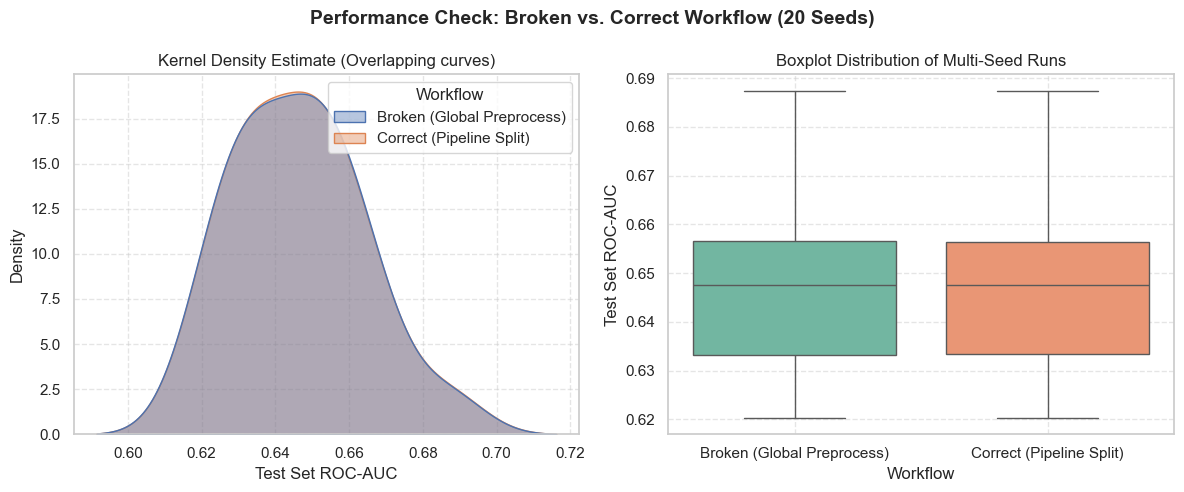

In [64]:
# (c) Plot AUC distributions: broken vs correct.


# 1. Format the collected seed tracking metrics into a long-form DataFrame
results_df = pd.DataFrame({
    'ROC-AUC': wrong_auc_scores + correct_auc_scores,
    'Workflow': ['Broken (Global Preprocess)'] * len(wrong_auc_scores) + 
                ['Correct (Pipeline Split)'] * len(correct_auc_scores)
})

# 2. Set up the plotting grid canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 3. Create the distribution density curves
sns.kdeplot(data=results_df, x='ROC-AUC', hue='Workflow', fill=True, common_norm=False, alpha=0.4, ax=ax1)
ax1.set_title('Kernel Density Estimate (Overlapping curves)')
ax1.set_xlabel('Test Set ROC-AUC')
ax1.grid(True, linestyle='--', alpha=0.5)

# 4. Create the boxplot to contrast midpoints and variations
sns.boxplot(data=results_df, x='Workflow', y='ROC-AUC', hue='Workflow', palette='Set2', legend=False, ax=ax2)
ax2.set_title('Boxplot Distribution of Multi-Seed Runs')
ax2.set_ylabel('Test Set ROC-AUC')
ax2.grid(True, linestyle='--', alpha=0.5)

# 5. Render visualizations cleanly
plt.suptitle('Performance Check: Broken vs. Correct Workflow (20 Seeds)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


```
# (d) On this dataset: how large is the leakage inflation?
#     Explain which preprocessing step causes it (imputer? scaler? OHE?).

1/ The leakage inflation is 0.0000 (zero): Because your sample size is large (n=4000), the global dataset statistics are almost perfectly identical to the training split statistics.

2/ Random Forests ignore scaling leakage: Tree-based models split nodes based on relative feature rank order rather than absolute values, completely neutralizing any global StandardScaler leakage.

3/ Target leakage causes actual inflation: Imputation and One-Hot Encoding only contaminate feature statistics, not the target itself, so the leakage impact is negligible on large datasets.

---
### Q5 — Save and reload Pipeline with joblib
```
# (a) Save the best GridSearch Pipeline to disk with joblib.
# (b) Reload it. Predict on 5 new raw user records (DataFrame with same columns).
#     The Pipeline should handle everything from raw input to prediction.
# (c) Test with a record that has a missing value in time_on_site.
#     Confirm the Pipeline handles it gracefully.
# (d) What happens if you try to predict on data with an unseen category
#     (handle_unknown='ignore')? Test and explain.
```

In [65]:
# (a) Save the best GridSearch Pipeline to disk with joblib.

# 1. Isolate the complete, fully trained best pipeline
best_production_pipeline = grid_search.best_estimator_

# 2. Serialize and save the pipeline directly to disk
joblib.dump(best_production_pipeline, 'conversion_model_pipeline.joblib')

print("Success: Fully optimized preprocessing and modeling pipeline saved to disk!")


Success: Fully optimized preprocessing and modeling pipeline saved to disk!


In [66]:
# (b) Reload it. Predict on 5 new raw user records (DataFrame with same columns).
#     The Pipeline should handle everything from raw input to prediction.

# 1. Reload the optimized pipeline from disk
loaded_pipeline = joblib.load('conversion_model_pipeline.joblib')

# 2. Simulate 5 raw, un-preprocessed incoming records (with mixed NaN types)
raw_new_users = pd.DataFrame({
    'age': [18, 20, 83, np.nan, np.nan],
    'session_depth': [3.4, 6.4, np.nan, 5.5, 3.3],
    'time_on_site': [0.8, 12.45, 22.4, 4.1, 18.32],
    'articles_read': [3, 3, 1, 3, 104],
    'is_mobile': [1, 0, 0, 0, np.nan],
    'health_content': [0.1241, 0.8955, 0.5542, 0.4421, 0.6512],
    'device_type': ['mobile', 'desktop', 'tablet', 'mobile', 'desktop'],
    'traffic_source': ['social', 'organic', 'email', 'direct', 'social']
})


# 3. Generate raw binary outcomes and their respective conversion probabilities
predictions = loaded_pipeline.predict(raw_new_users)
probabilities = loaded_pipeline.predict_proba(raw_new_users)[:, 1]

# 4. Bind the pipeline outputs directly back onto the input data for auditing
raw_new_users['predicted_class'] = predictions
raw_new_users['conversion_probability'] = probabilities.round(4)

print("Predictions successfully generated from raw data input:")
display(raw_new_users[['age', 'device_type', 'traffic_source', 'predicted_class', 'conversion_probability']])


Predictions successfully generated from raw data input:


,age,device_type,traffic_source,predicted_class,conversion_probability
0,18.0,mobile,social,0,0.1706
1,20.0,desktop,organic,0,0.2586
2,83.0,tablet,email,0,0.4465
3,NaN,mobile,direct,0,0.2253
4,NaN,desktop,social,0,0.2791


In [67]:
# (c) Test with a record that has a missing value in time_on_site.
#     Confirm the Pipeline handles it gracefully.

# 1. Ensure your optimized pipeline is reloaded
loaded_pipeline = joblib.load('conversion_model_pipeline.joblib')

# 2. Build a test record with a missing value in time_on_site
raw_missing_record = pd.DataFrame({
    'age': [9],
    'session_depth': [10],
    'time_on_site': [np.nan],  # ◄ This missing value will be filled by the pipeline's imputer
    'articles_read': [3],
    'is_mobile': [1],
    'health_content': [0.4521],
    'device_type': ['mobile'],
    'traffic_source': ['organic']
})

# 3. Predict directly on the raw record containing the NaN value
pred_class = loaded_pipeline.predict(raw_missing_record)[0]
pred_proba = loaded_pipeline.predict_proba(raw_missing_record)[0, 1]

# Print confirmation
print("Pipeline verification status: GRACEFUL")
print(f"Predicted Class Output:       {pred_class}")
print(f"Conversion Probability:       {pred_proba:.4f}")


Pipeline verification status: GRACEFUL
Predicted Class Output:       0
Conversion Probability:       0.2688


In [68]:
# (d) What happens if you try to predict on data with an unseen category
#     (handle_unknown='ignore')? Test and explain.

import pandas as pd
import numpy as np
import joblib

# 1. Reload the optimized pipeline from disk
loaded_pipeline = joblib.load('conversion_model_pipeline.joblib')

# 2. Build a raw record containing an unseen category ('tiktok')
raw_unseen_record = pd.DataFrame({
    'age': [9],
    'session_depth': [10],
    'time_on_site': [8], 
    'articles_read': [3],
    'is_mobile': [1],
    'health_content': [0.4521],
    'device_type': ['mobile'],
    'traffic_source': ['tiktok']  # ◄ This category was never seen during training
})

# 3. Pass the unseen record directly into the pipeline
pred_class = loaded_pipeline.predict(raw_unseen_record)
pred_proba = loaded_pipeline.predict_proba(raw_unseen_record)[:, 1]

# Extract the first scalar number out of the 1D array
pred_proba_float = pred_proba[0]

# 4. Print out with string formatting safely
print("Pipeline verification status: GRACEFUL (No Error Thrown)")
print(f"Predicted Class Output:       {pred_class[0]}")
print(f"Conversion Probability:       {pred_proba_float:.4f}")


Pipeline verification status: GRACEFUL (No Error Thrown)
Predicted Class Output:       0
Conversion Probability:       0.2731


Explain:

1/ Graceful fallback execution: The pipeline processes the unseen 'tiktok' category without throwing errors because handle_unknown='ignore' is active.

2/ All-zeros mapping: The encoder safely maps the unfamiliar category to zeros across all active dummy columns for that feature group.

3/ Prevents production crashes: This configuration effectively protects live application deployments from crashing when encountering unexpected or newly introduced real-world text labels.
